# Problem Statement

A **telecommunications company** launching **a new marketing campaign** seeks to 
**identify which customer segments respond most effectively** to promotional 
activities, in order to allocate campaign resources efficiently and 
maximise subscription rates.

# Import and Load data

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

# ignore warnings
warnings.filterwarnings("ignore")

In [ ]:
# read raw data
df_raw = pd.read_csv('TeleCom_Data-1.csv', sep = ";",header=None)

# structure data
df_raw = df_raw[0].str.split(";",expand=True)
df_raw = df_raw.replace('"', '', regex=True)
df_raw.columns = df_raw.iloc[0]
df_raw = df_raw[1:]

all_column_list =list(df_raw.columns)

In [292]:
df_raw.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
1,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191,no
2,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191,no
3,45,services,married,basic.9y,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191,no
4,59,admin.,married,professional.course,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191,no
5,41,blue-collar,married,unknown,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191,no


In [293]:
df_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41180 entries, 1 to 41180
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             41180 non-null  object
 1   job             41180 non-null  object
 2   marital         41180 non-null  object
 3   education       41180 non-null  object
 4   default         41180 non-null  object
 5   housing         41180 non-null  object
 6   loan            41180 non-null  object
 7   contact         41180 non-null  object
 8   month           41180 non-null  object
 9   day_of_week     41180 non-null  object
 10  duration        41180 non-null  object
 11  campaign        41180 non-null  object
 12  pdays           41180 non-null  object
 13  previous        41180 non-null  object
 14  poutcome        41180 non-null  object
 15  emp.var.rate    41180 non-null  object
 16  cons.price.idx  41180 non-null  object
 17  cons.conf.idx   41180 non-null  object
 18  euribo

In [294]:
df_raw.isna().sum()

0
age               0
job               0
marital           0
education         0
default           0
housing           0
loan              0
contact           0
month             0
day_of_week       0
duration          0
campaign          0
pdays             0
previous          0
poutcome          0
emp.var.rate      0
cons.price.idx    0
cons.conf.idx     0
euribor3m         0
nr.employed       0
y                 0
dtype: int64

In [295]:
df_raw.shape

(41180, 21)

In [296]:
df_raw.duplicated().sum()   # check for duplicates

np.int64(12)

**Findings**:
- Dataset contains 41,188 rows and 21 columns.
- Column 'pdays' contains many missing values (999 or NaN).
- 12 duplicated rows are detected.

# Data Cleaning

In [297]:
# copy
df_clean = df_raw.copy()

In [298]:
# remove duplicates
df_clean = df_clean.drop_duplicates()       # drop duplicates

In [299]:
# replace 'nonexistent' with NaN  # nonexistent  sholud be keep
# df_clean['poutcome'] = df_clean['poutcome'].replace({'nonexistent':'NaN'})

# rows with previous = 0 and pdays = Nan, replace pdays with -1
df_clean.loc[(df_clean['previous'] == 0) & (df_clean['pdays'] == 'NaN'), 'pdays'] = -1

In [300]:
# convert y to binary 
df_clean['y'] = df_clean['y'].replace({'no':0,'yes':1})

# turn into numeric types
c = ['age','pdays','campaign','previous','duration','cons.price.idx','cons.conf.idx','nr.employed','euribor3m', 'emp.var.rate']
for i,k in enumerate(c):
    df_clean[k] = pd.to_numeric(df_clean[k], errors='coerce')

In [301]:
df_clean['pdays_group'] = np.where(df_clean['pdays'] == 999, 'no_record', 'recorded')
pd.crosstab(df_clean['pdays_group'] , df_clean['poutcome'])

poutcome,failure,nonexistent,success
pdays_group,,,
no_record,4108,35547,0
recorded,142,0,1371


In [302]:
pd.crosstab(df_raw['previous'] , df_raw['poutcome'])

poutcome,failure,nonexistent,success
previous,,,
0,0,35559,0
1,3695,0,864
2,434,0,320
3,88,0,128
4,29,0,40
5,3,0,15
6,1,0,3
7,0,0,1


In [303]:
# replace 999 with Nan
df_clean['pdays'] = df_clean['pdays'].replace({999: np.nan})

# drop temporary column
df_clean = df_clean.drop(columns=['pdays_group'])

**Findings:**
- `pdays = 999` does not mean "never contacted" — it represents missing contact history
- When `poutcome = nonexistent`, `pdays` is always 999
- When `poutcome = failure`, `pdays` can still be 999 (4,108 rows), 
  suggesting the previous contact was too long ago to be recorded
- Only `poutcome = success` rows have valid `pdays` values

Given these findings, 999 is treated as a missing value indicator 
rather than a definitive "never contacted" flag.

# Exploratory Data Analysis

##  Overview

In [304]:
df = df_clean.copy()

In [305]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 41168 entries, 1 to 41180
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41168 non-null  int64  
 1   job             41168 non-null  object 
 2   marital         41168 non-null  object 
 3   education       41168 non-null  object 
 4   default         41168 non-null  object 
 5   housing         41168 non-null  object 
 6   loan            41168 non-null  object 
 7   contact         41168 non-null  object 
 8   month           41168 non-null  object 
 9   day_of_week     41168 non-null  object 
 10  duration        41168 non-null  int64  
 11  campaign        41168 non-null  int64  
 12  pdays           1513 non-null   float64
 13  previous        41168 non-null  int64  
 14  poutcome        41168 non-null  object 
 15  emp.var.rate    41168 non-null  float64
 16  cons.price.idx  41168 non-null  float64
 17  cons.conf.idx   41168 non-null  floa

<Figure size 640x480 with 0 Axes>

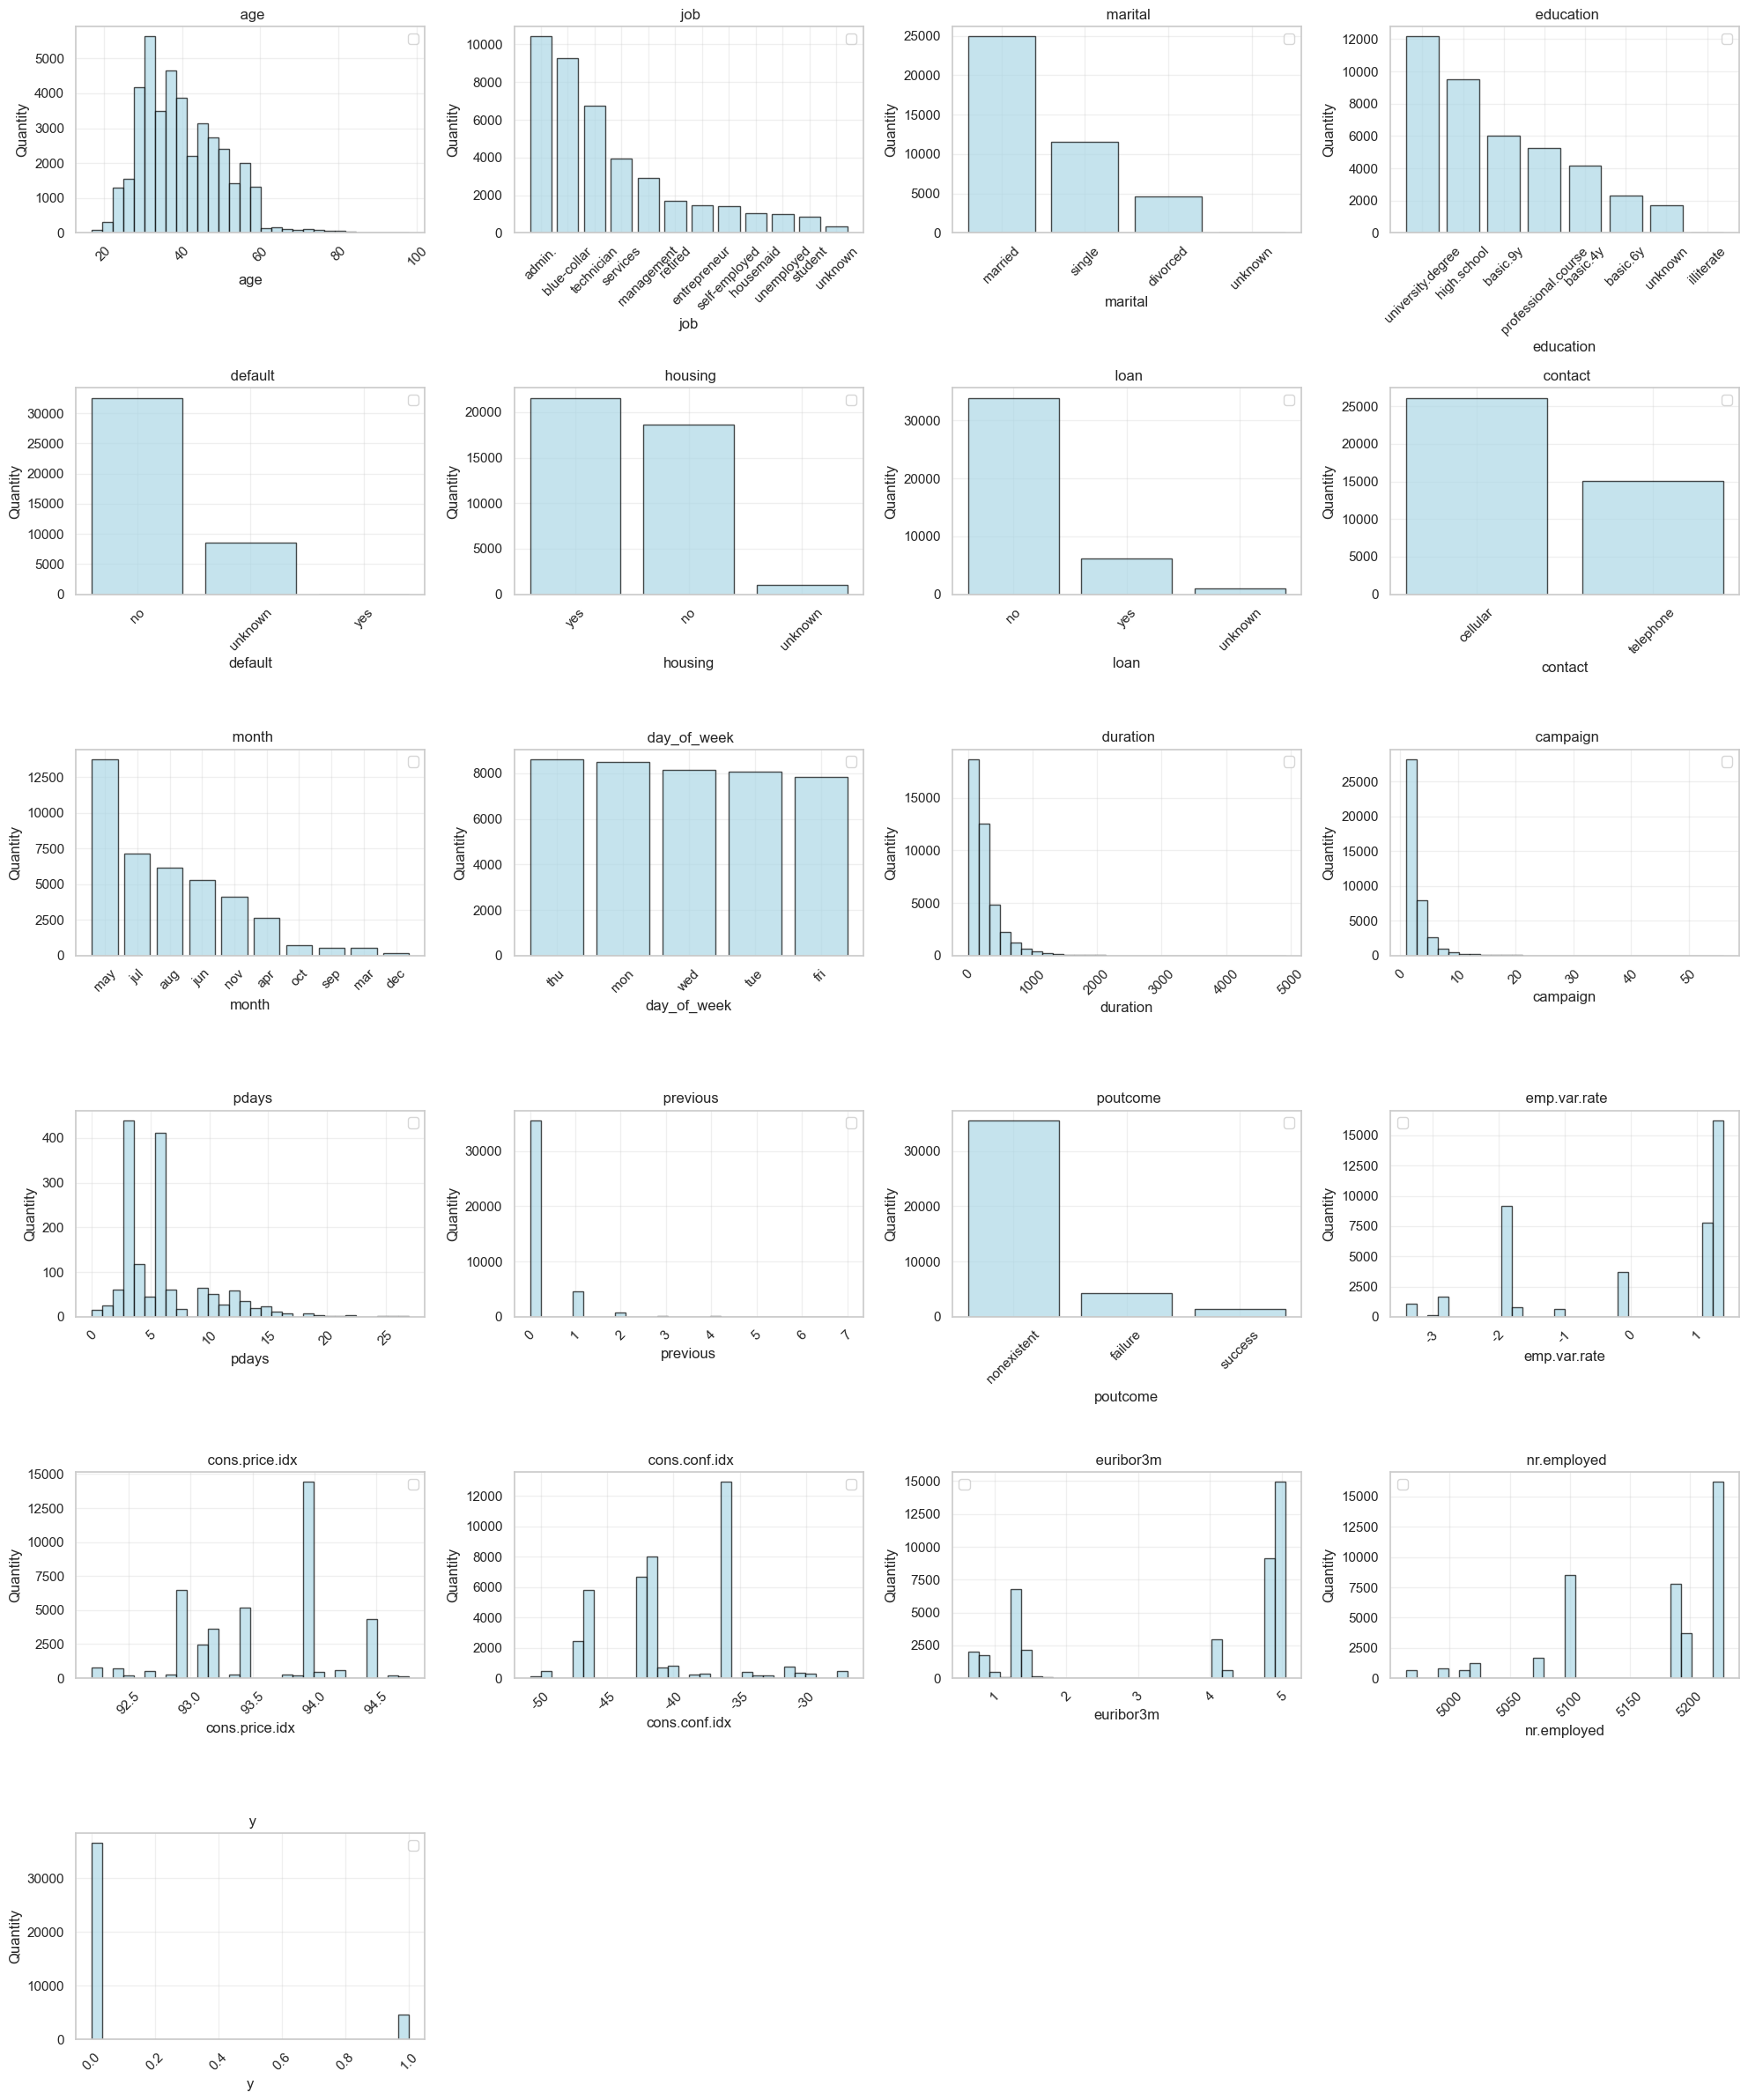

In [ ]:
# Distribution of all features

plt.figure()
fig, axes =plt.subplots(6,4,figsize=(20,24))  # wide, high
axes = axes.flatten()

for i,k in enumerate(all_column_list):

    if df[k].dtype == 'object':  # categorical
        frequences_k = df[k].value_counts()
        axes[i].bar(frequences_k.index, frequences_k.values, 
                    color='lightblue', alpha=0.7, edgecolor='black')
    else:  # numerical
        axes[i].hist(df[k].dropna(), bins=30, 
                     color='lightblue', alpha=0.7, edgecolor='black')

    axes[i].tick_params(axis='x' ,rotation=45)
    axes[i].set_xlabel(k)
    axes[i].set_ylabel('Quantity')
    axes[i].set_title(f' {k}')
    axes[i].grid(True, alpha=0.3)
    axes[i].legend()

for j in range(len(all_column_list), len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

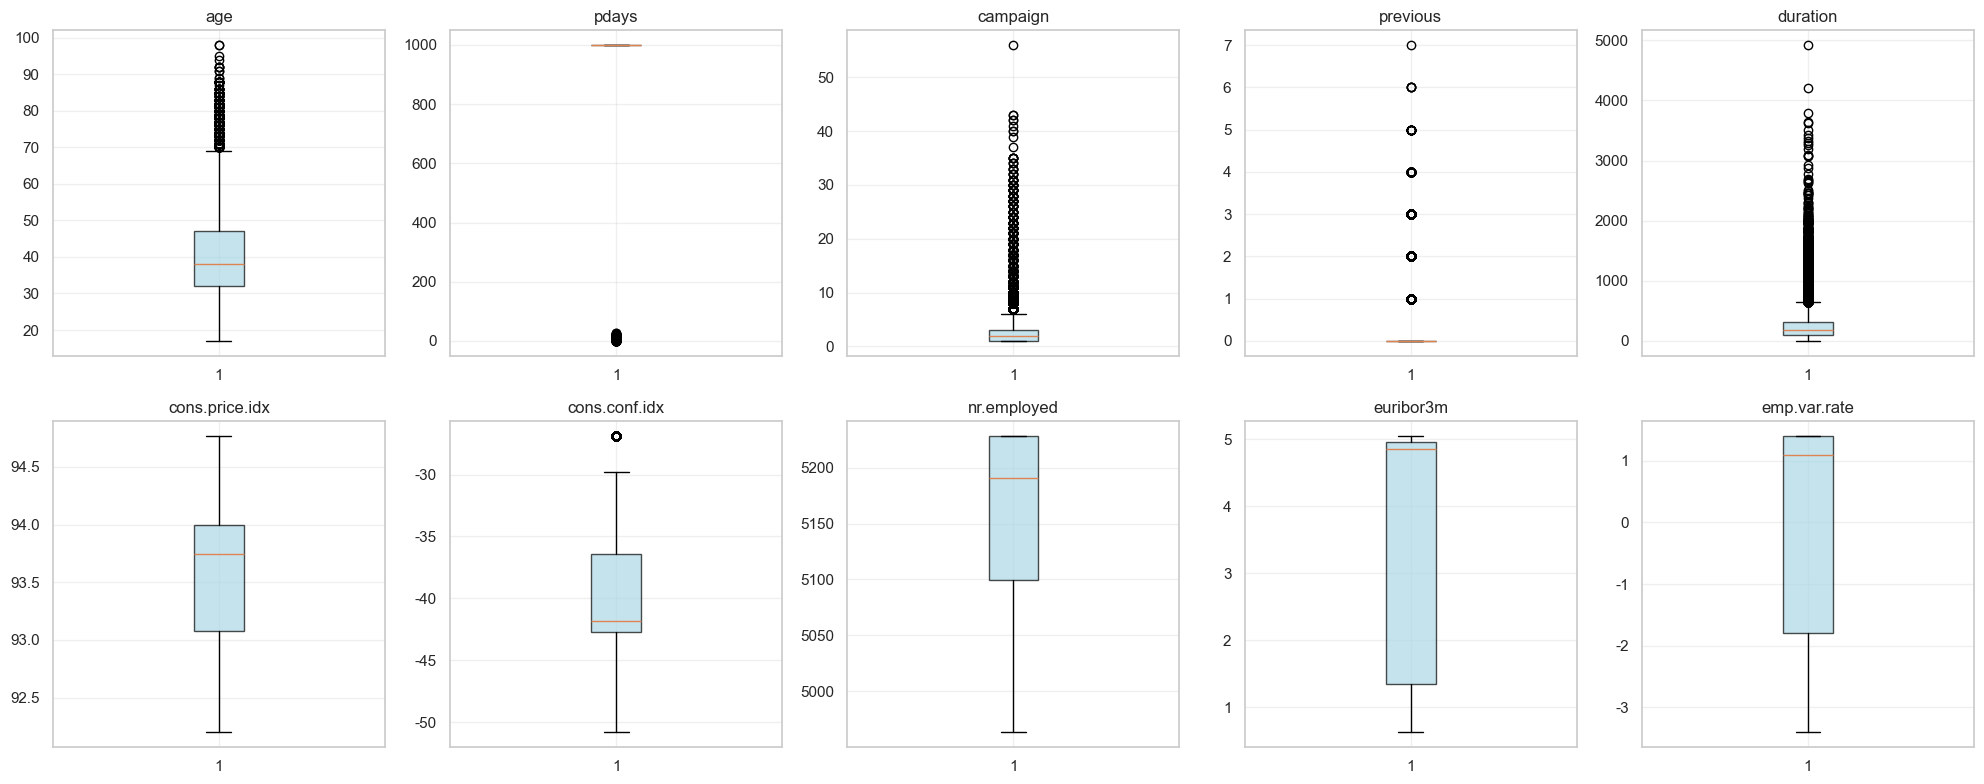

In [ ]:
# boxplot for numerical variables (outliers)

c = ['age','pdays','campaign','previous','duration','cons.price.idx','cons.conf.idx','nr.employed','euribor3m', 'emp.var.rate']

fig, axes = plt.subplots(2, 5, figsize=(20, 8))
axes = axes.flatten()

for i, k in enumerate(c):
    axes[i].boxplot(df[k].dropna(), patch_artist=True,
                    boxprops=dict(facecolor='lightblue', alpha=0.7))
    axes[i].set_title(k)
    axes[i].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [169]:
df['campaign'].describe()

count    41168.000000
mean         2.568087
std          2.770530
min          1.000000
25%          1.000000
50%          2.000000
75%          3.000000
max         56.000000
Name: campaign, dtype: float64

In [324]:
tem_df = df[df['campaign'] > 20]

print(f'Outlier = campaign > 20')
print(f'Number of outlier records: {tem_df.shape[0]}')
print(f'Number of missing values in pdays: {tem_df["pdays"].isna().sum()}\n')
print(f'distribution of poutcome:\n{tem_df["poutcome"].value_counts()}')
tem_df.shape

Outlier = campaign > 20
Number of outlier records: 157
Number of missing values in pdays: 157

distribution of poutcome:
poutcome
nonexistent    157
Name: count, dtype: int64


(157, 21)

**Findings**:

- **age:** max value (~98) is plausible in real world — no action needed
- **duration:** occurs after the phone call ends, posing a data leakage risk — retained in EDA but will be removed before modelling
- **campaign outlier:** extreme values (>20) show no previous contact record — whether to treat as noise or retain will be determined in Bivariate Analysis

## Features vs. Target
This section explores the relationship between individual features and the target variable (y) to identify potential predictors of subscription.

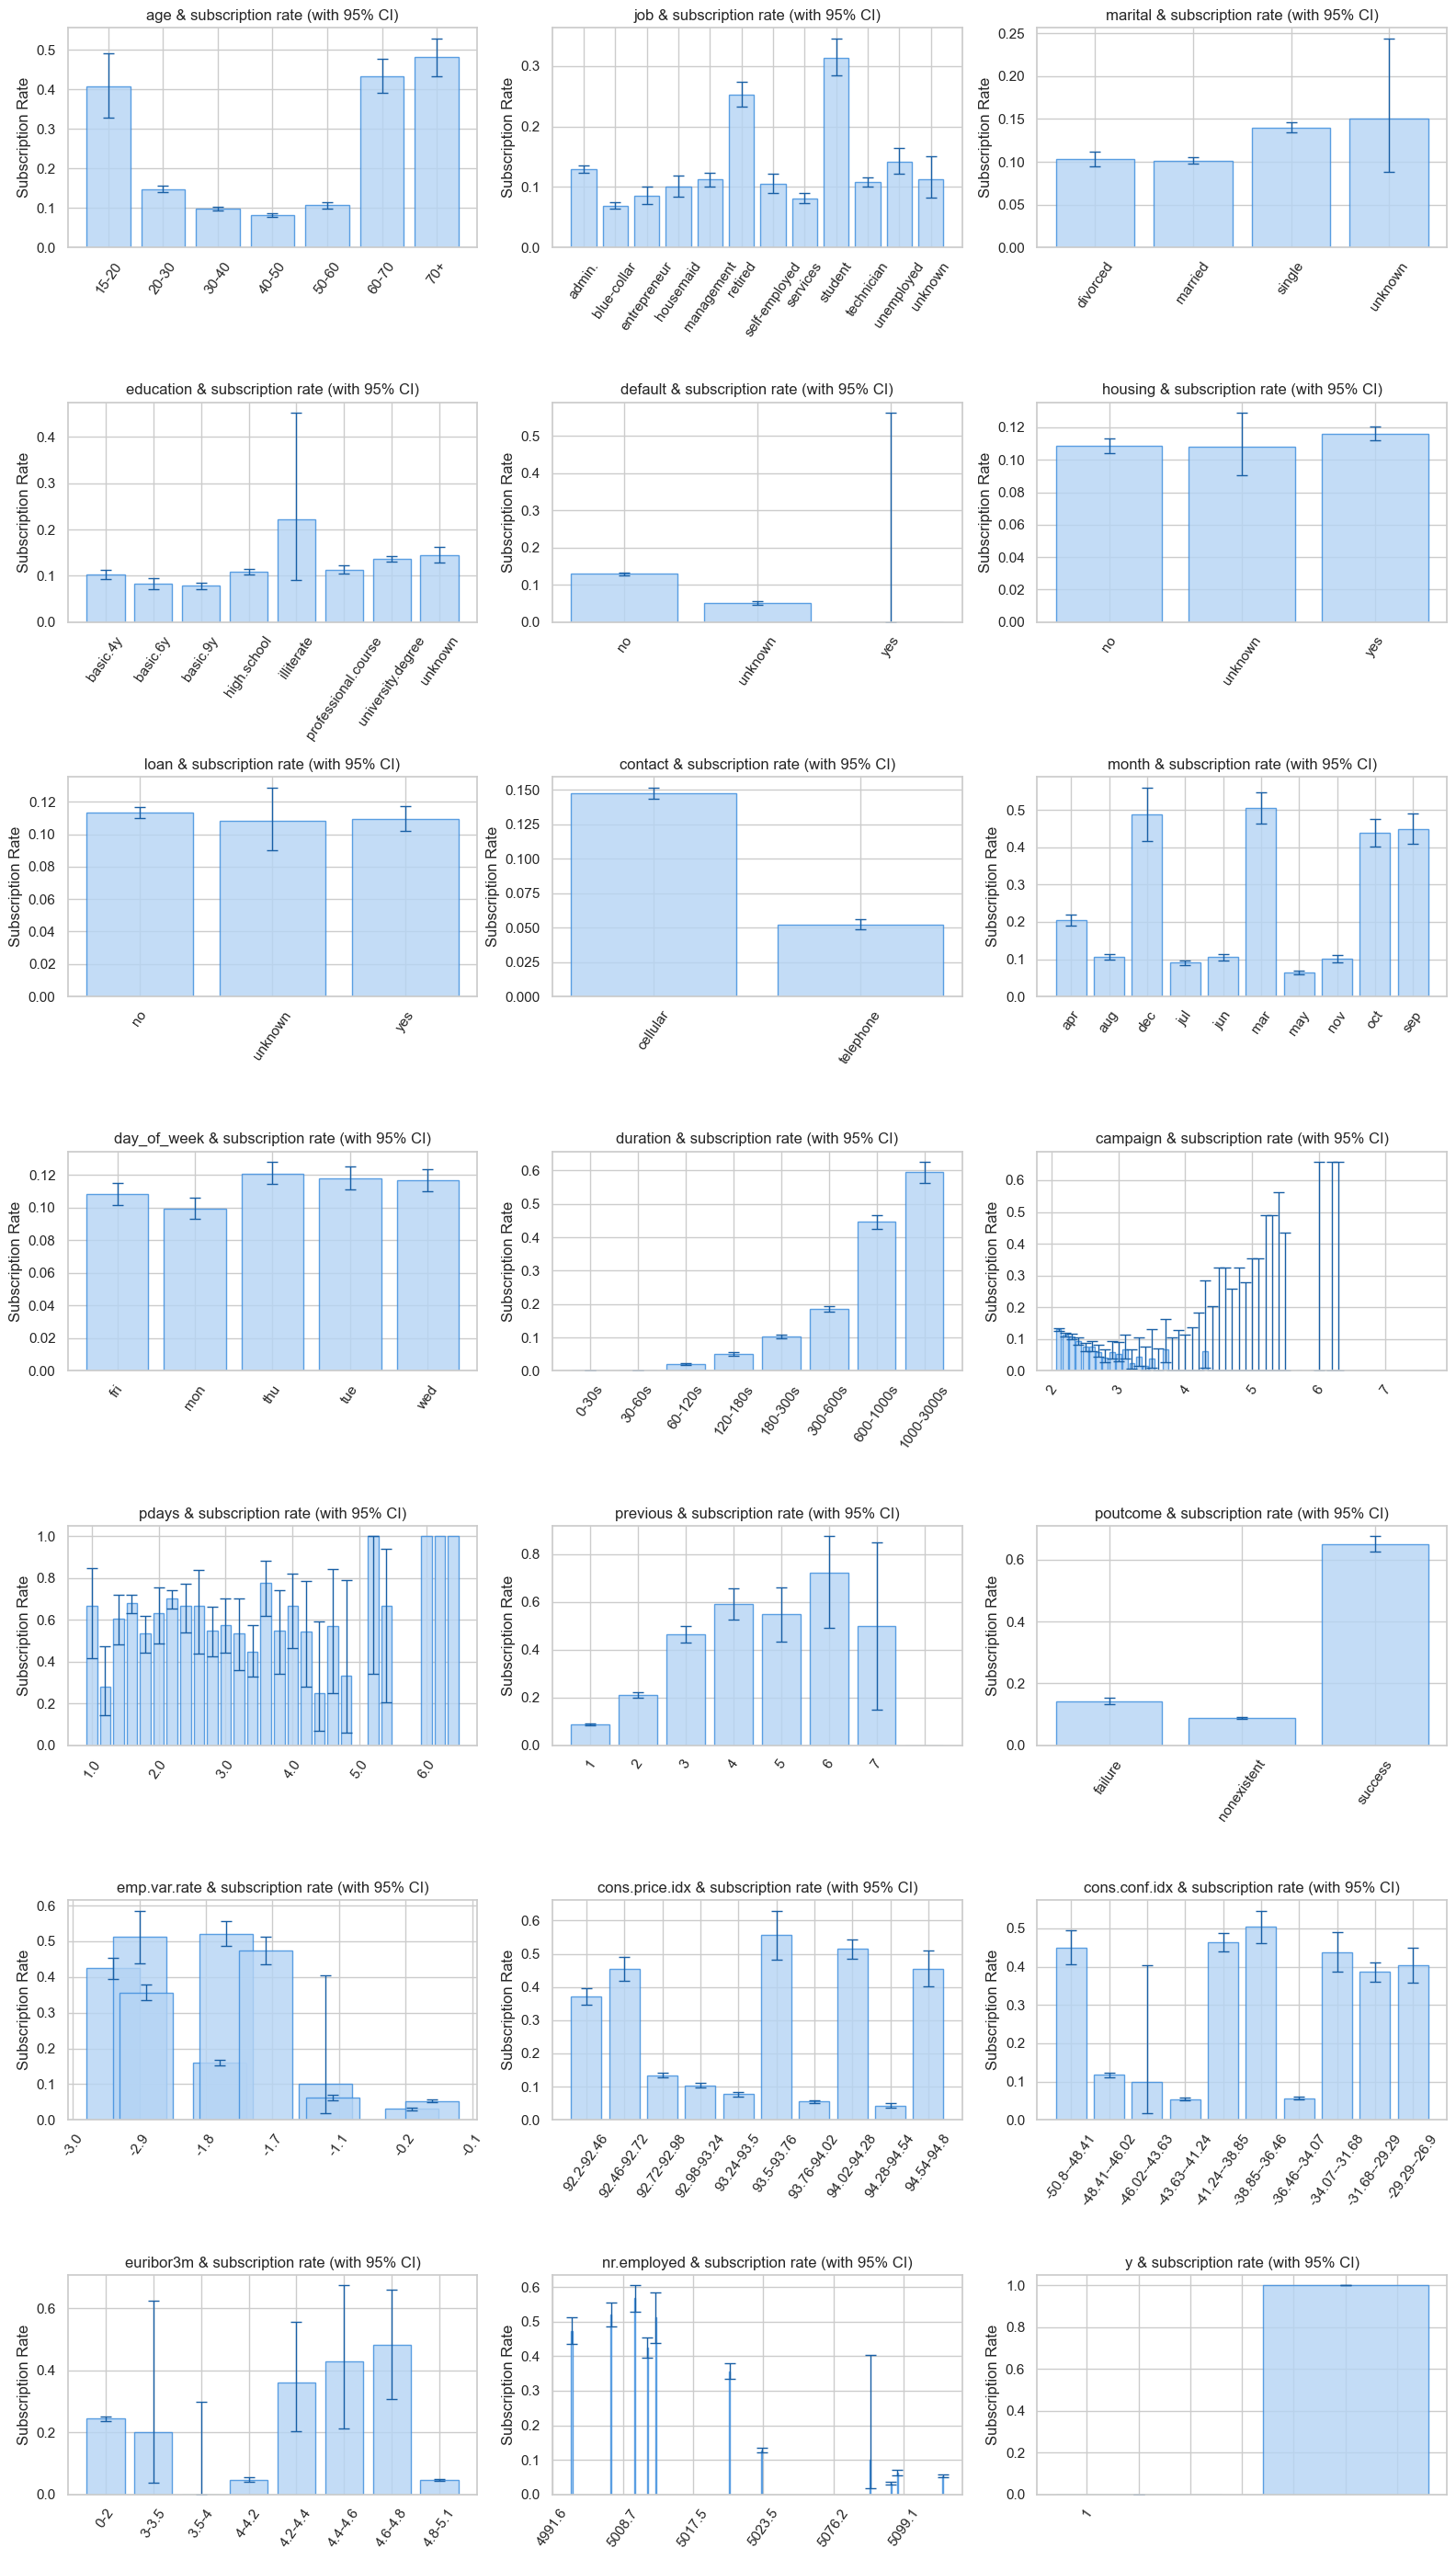

In [416]:
# feature vs subscription rate (with 95% confidence interval)

fig, axes = plt.subplots(7, 3, figsize=(16, 28))
axes = axes.flatten()

for i, k in enumerate(all_column_list):

    # binning logic 
    if k in ['cons.price.idx']:
        bins = [92.200,92.460,92.720,92.980,93.240,93.500,93.760,94.020,94.280,94.540,94.800]
        labels = ['92.2-92.46', '92.46-92.72', '92.72-92.98', '92.98-93.24', '93.24-93.5', '93.5-93.76', '93.76-94.02', '94.02-94.28', '94.28-94.54', '94.54-94.8']
        group = pd.cut(df[k], bins=bins, labels=labels)

    elif k in ['cons.conf.idx']:
        bins = [-50.8, -48.41, -46.02, -43.63, -41.24, -38.85, -36.46, -34.07, -31.68, -29.29, -26.9]
        labels = ['-50.8--48.41', '-48.41--46.02', '-46.02--43.63', '-43.63--41.24', '-41.24--38.85', '-38.85--36.46', '-36.46--34.07', '-34.07--31.68', '-31.68--29.29', '-29.29--26.9']
        group = pd.cut(df[k], bins=bins, labels=labels)

    elif k in ['euribor3m']:
        bins = [0,2,3,3.5,4,4.2,4.4,4.6,4.8,5.1]
        labels = ['0-2', '2-3', '3-3.5', '3.5-4', '4-4.2', '4.2-4.4', '4.4-4.6', '4.6-4.8','4.8-5.1']
        group = pd.cut(df[k], bins=bins, labels=labels)

    elif k in ['age']:
        bins = [15,20,30,40,50,60,70,100]
        labels=['15-20','20-30','30-40','40-50','50-60','60-70','70+']
        group = pd.cut(df[k], bins=bins, labels=labels)

    elif k in ['duration']:
        bins = [0,30,60,120,180,300,600,1000,3000]
        labels = ['0-30s', '30-60s', '60-120s', '120-180s', '180-300s', '300-600s', '600-1000s', '1000-3000s']
        group = pd.cut(df[k], bins=bins, labels=labels)

    else:
        group = df[k]


    # describe subscription rate by group
    subscription_rate = df.groupby(group, observed=True)['y'].mean()

    # calculate 95% confidence interval
    ci_low = []
    ci_high = []

    for cat in subscription_rate.index:
        subset = df[group == cat]['y']
        if len(subset) > 1:
            ci = sm.stats.proportion_confint(subset.sum(), len(subset), alpha=0.05, method='wilson')
            ci_low.append(ci[0])
            ci_high.append(ci[1])
        else:
            ci_low.append(np.nan)
            ci_high.append(np.nan)

    # plot bar + error bar
    ax = axes[i]
    ax.bar(subscription_rate.index, subscription_rate.values,
           color='#B5D4F4', alpha=0.8, edgecolor='#378ADD')

    ax.errorbar(subscription_rate.index,
                subscription_rate.values,
                yerr = [
                    np.abs(subscription_rate.values - np.array(ci_low)),
                    np.abs(np.array(ci_high) - subscription_rate.values)
                ],
                fmt='none', ecolor='#185FA5', capsize=4, linewidth=1)

    ax.set_xticklabels(subscription_rate.index, rotation=55)
    ax.set_ylabel("Subscription Rate")
    ax.set_title(f'{k} & subscription rate (with 95% CI)')

plt.tight_layout()
plt.show()


,Lower Whisker,Q1 (25%),Median (50%),Q3 (75%),Upper Whisker
y=0,17,32.0,38.0,47.0,69.5
y=1,17,31.0,37.0,50.0,78.5


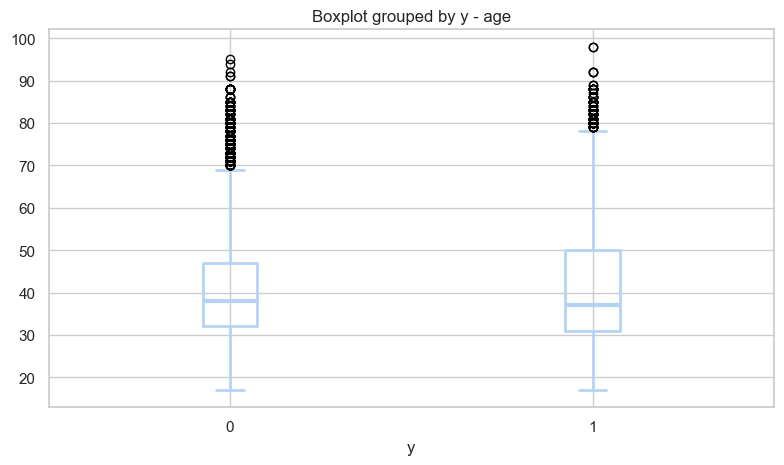

,Lower Whisker,Q1 (25%),Median (50%),Q3 (75%),Upper Whisker
y=0,1,1.0,2.0,3.0,6.0
y=1,1,1.0,2.0,2.0,3.5


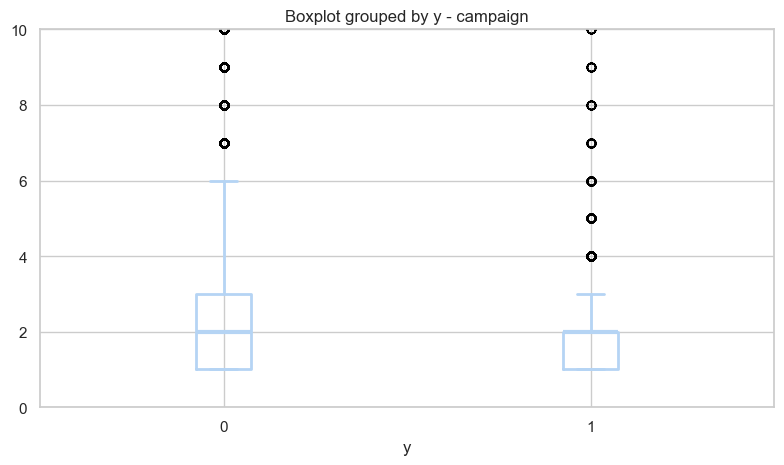

In [ ]:
columns = ['age', 'campaign']
df['campaign'] = pd.to_numeric(df['campaign'], errors='coerce')

def get_boxplot_stats(data):
    stats = {}
    stats['Min'] = data.min()
    stats['Q1 (25%)'] = data.quantile(0.25)
    stats['Median (50%)'] = data.median()
    stats['Q3 (75%)'] = data.quantile(0.75)
    stats['Max'] = data.max()
    IQR = stats['Q3 (75%)'] - stats['Q1 (25%)']
    stats['Lower Whisker'] = max(stats['Min'], stats['Q1 (25%)'] - 1.5 * IQR)
    stats['Upper Whisker'] = min(stats['Max'], stats['Q3 (75%)'] + 1.5 * IQR)
    return stats

for k in columns:
    # table
    group0_stats = get_boxplot_stats(df[df['y']==0][k])
    group1_stats = get_boxplot_stats(df[df['y']==1][k])

    summary_df = pd.DataFrame([group0_stats, group1_stats], index=['y=0', 'y=1'])
    summary_df = summary_df[['Lower Whisker', 'Q1 (25%)', 'Median (50%)', 'Q3 (75%)', 'Upper Whisker']]
    display(summary_df.round(1))

    # plot
    fig, ax = plt.subplots(figsize=(8, 5))
    df.boxplot(column=k, by='y', ax=ax, color='#B5D4F4', 
               boxprops=dict(linewidth=2, color='#B5D4F4'),
               whiskerprops=dict(linewidth=2, color='#B5D4F4'),
               capprops=dict(linewidth=2, color='#B5D4F4'),
                medianprops=dict(linewidth=3, color='#B5D4F4')
                )
          
    if k == 'campaign':
        ax.set_ylim(0, 10)
    ax.set_title(f'Boxplot grouped by y - {k}')
    plt.suptitle('')
    plt.tight_layout()
    plt.show()

**Findings**:
- **Unreliable high subscription rates:** some groups show high subscription 
  rates but are statistically unreliable due to small sample sizes and 
  wide confidence intervals, including:
  - age < 20 and age > 60
  - marital = unknown
  - education = illiterate
  - month = december
  - previous > 3
  
  These groups should be interpreted with caution in downstream analysis.


- Age alone is not a strong predictor — median age of subscribers (37) 
  and non-subscribers (38) are nearly identical
- Although 15-20 and 60+ appear to have higher subscription rates, 
  their wide confidence intervals and small sample sizes make these 
  results statistically unreliable
- **Conclusion: age is not a reliable standalone predictor of subscription**

### Correlation Analysis

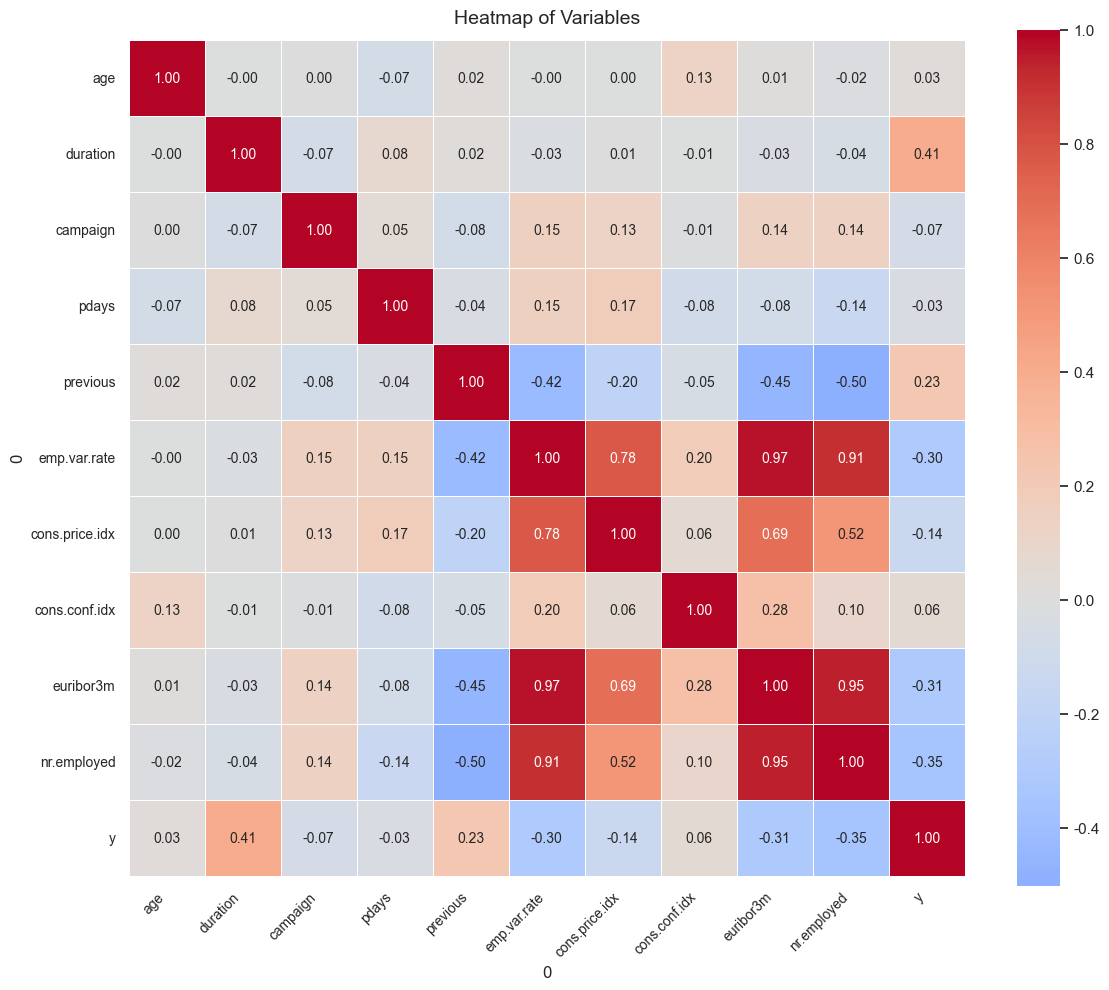

In [341]:
def create_plot_heatmap(df, column_list, figsize=(12, 10)):
    numeric_cols = []
    for col in column_list:
        if col in df.columns:
            if df[col].dtype in ['int64', 'float64']:
                numeric_cols.append(col)

    subset_df = df[numeric_cols]
    corr_matrix = subset_df.corr()

    plt.figure(figsize=figsize)
    sns.heatmap(corr_matrix,
                annot=True,
                cmap='coolwarm',
                center=0,
                square=True,
                fmt='.2f',
                linewidths=0.5,
                annot_kws={'size': 10})
    plt.title('Heatmap of Variables', fontsize=14, pad=12)
    plt.xticks(rotation=45, ha='right', fontsize=10)
    plt.yticks(rotation=0, fontsize=10)
    plt.tight_layout()
    plt.savefig('heatmap.png', dpi=300, bbox_inches='tight')
    plt.show()

create_plot_heatmap(df, all_column_list)

**Findings**:
1. Duration shows the strongest correlation with y (r = 0.41).
2. Economic indicators are highly correlated with one another.
3. These economic indicators also show a moderate correlation with y, suggesting that the broader economic environment may influence subscription likelihood.

## Feature Deep Dive

A deeper analysis of notable features identified in the previous section.

### Compare Job vs. age group and Degree vs. age group

Subscription rates are compared across job and education combinations by age group, focusing only on segments with sufficient sample size (≥ 5% of total). The target rate is set at 15%, notably higher than the overall average of 11.26%.

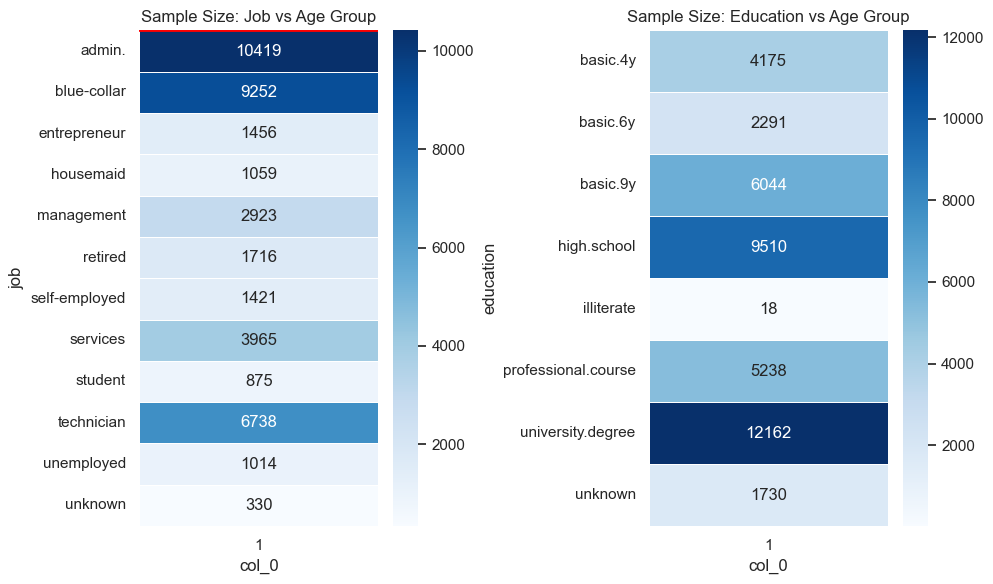

In [ ]:
# check sample size of each combination

fig, axes = plt.subplots(1, 2, figsize=(10, 6))

# job vs age_group
j_combo = pd.crosstab(df['job'], group)
sns.heatmap(j_combo, annot=True, fmt='d', cmap='Blues', 
            ax=axes[0], linewidths=0.5)
axes[0].set_title('Sample Size: Job vs Age Group')
axes[0].axhline(y=0, color='red', linewidth=2)

# education vs age_group  
e_combo = pd.crosstab(df['education'], group)
sns.heatmap(e_combo, annot=True, fmt='d', cmap='Blues',
            ax=axes[1], linewidths=0.5)
axes[1].set_title('Sample Size: Education vs Age Group')

plt.tight_layout()
plt.show()

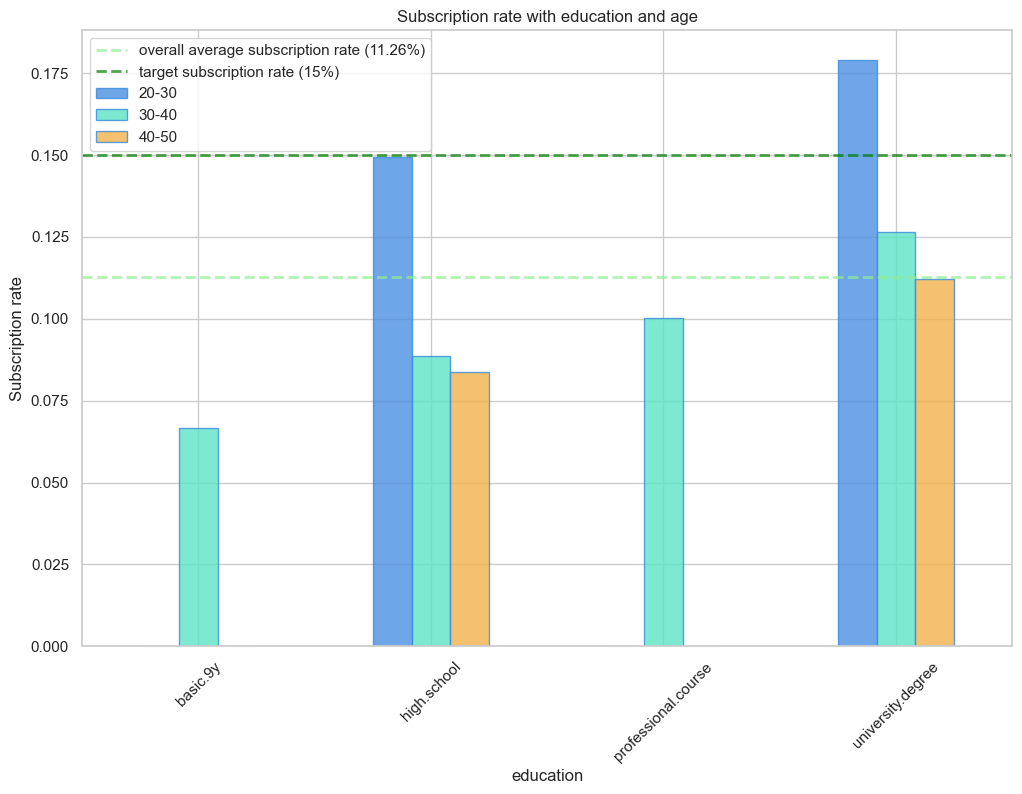

In [415]:
oal = df['y'].mean()
c = ['education', 'age']

# create age groups
bins = [15,20,30,40,50,60,70,100]
labels=['15-20','20-30','30-40','40-50','50-60','60-70','70+']
df['age_group'] = pd.cut(df['age'], bins=bins, labels=labels)

# define colors 
colors = ['#4A90E2', "#5CE4C6AE", "#F1B24BC5", '#D0021B', '#9013FE', '#B8E986']

for k in c:
    if k == 'age':  # age is already grouped, so skip
        continue

    combination_counts = df.groupby([k, 'age_group'], observed=True).size()
    valid_combinations = combination_counts[combination_counts >= 2059].index

    mask = df.set_index([k, 'age_group']).index.isin(valid_combinations)
    filtered_df = df[mask]

    combination_rate = filtered_df.groupby([k, 'age_group'], observed=True)['y'].mean()

    combination_rate.unstack().plot(kind='bar', figsize=(12, 8), color=colors[:len(combination_rate.unstack().columns)], alpha=0.8, edgecolor='#378ADD')
    plt.axhline(oal, color='lightgreen', linestyle='--', alpha=0.7, linewidth=2,
                label=f'overall average subscription rate ({oal:.2%})')
    plt.axhline(0.15, color='green', linestyle='--', alpha=0.7, linewidth=2,
                label='target subscription rate (15%)')
    plt.title(f'Subscription rate with {k} and age')
    plt.ylabel('Subscription rate')
    plt.xticks(rotation=45)
    plt.legend()

plt.show()


**Findings**:
1. Only two groups meet the target subscription rate (15%): university degree and high school customers aged 20–30, making age 20–30 a key segment.
2. University degree holders consistently show subscription rates at or above the overall average across all age groups.

### 20-30 years group behavioural patterns

Customers aged 20-30 with university degrees showed the highest subscription rate (17.8%) — this section explores their behavioural patterns in depth.

In [ ]:
# cut age into groups
bins = [15,20,30,40,50,60,70,100]
labels=['15-20','20-30','30-40','40-50','50-60','60-70','70+']
group = pd.cut(df['age'], bins=bins, labels=labels)
df_age_between_20_30 = df[group == '20-30']

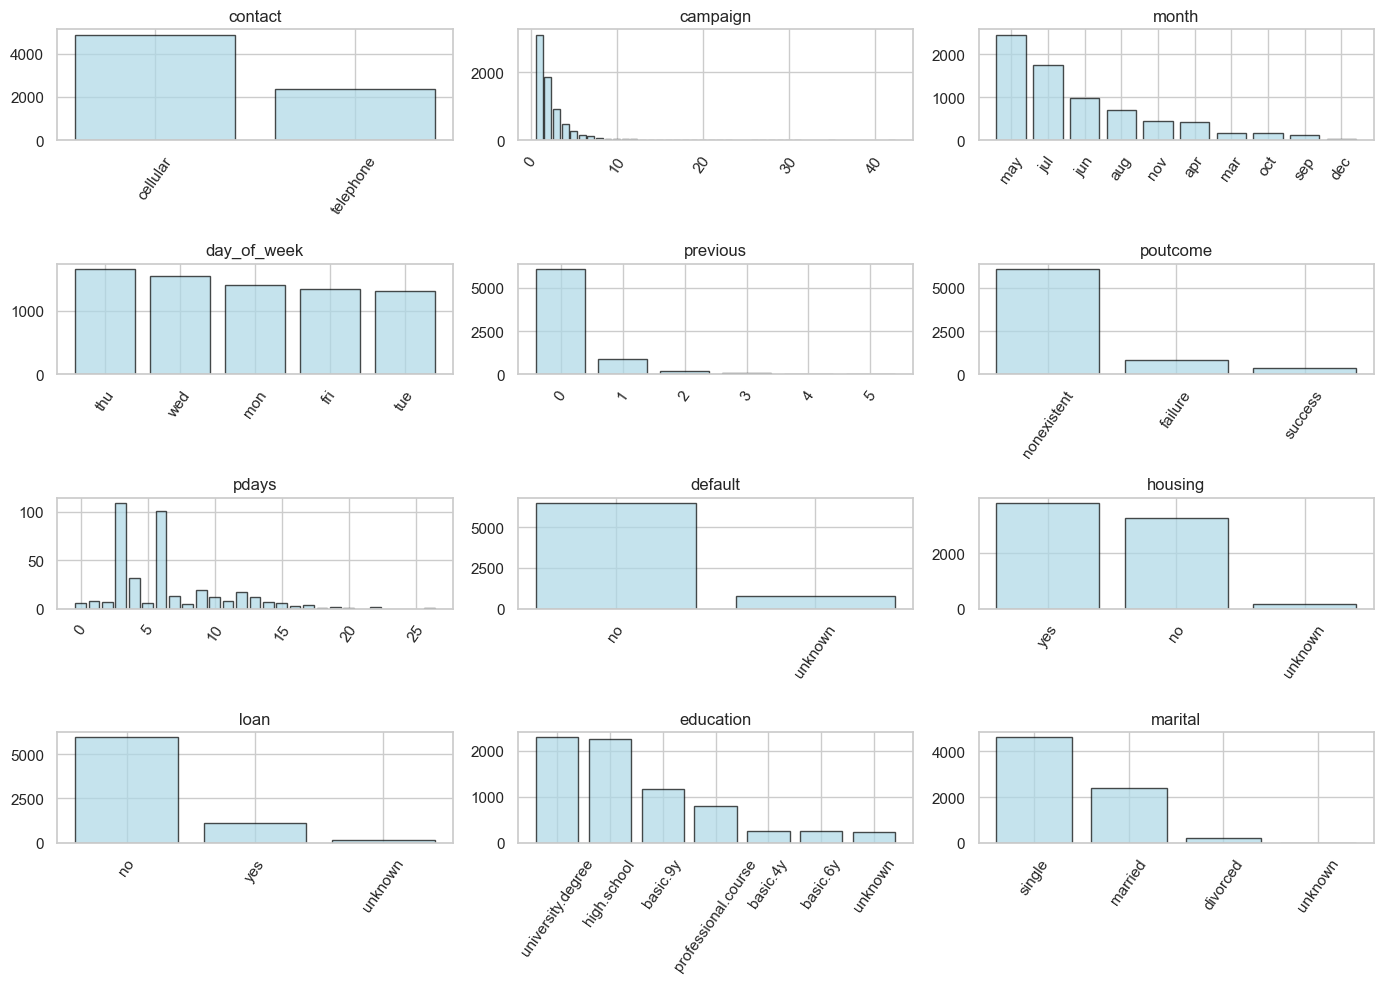

In [ ]:
# distribution of age between 20 and 30

fig, axes = plt.subplots(4,3,figsize= (14,10))
axes = axes.flatten()
e = ['contact','campaign','month','day_of_week','previous','poutcome','pdays','default','housing','loan','education','marital']
for i,k in enumerate(e) :
    w = df_age_between_20_30[k].value_counts()
    axes[i].bar(w.index,w.values,color='lightblue', alpha=0.7, edgecolor='black')
    axes[i].set_title(k)
    axes[i].tick_params(axis='x', rotation=55)

plt.tight_layout()
plt.savefig('20-30 behaviour', dpi=300, bbox_inches='tight')
plt.show()

In [406]:
pd.crosstab(df_age_between_20_30['poutcome'], df_age_between_20_30['y'], normalize='index', margins=True, margins_name='Total')

y,0,1
poutcome,,
failure,0.833333,0.166667
nonexistent,0.881745,0.118255
success,0.376471,0.623529
Total,0.852645,0.147355


In [407]:
pd.crosstab(df['poutcome'], df['y'], normalize='index', margins=True, margins_name='Total')

y,0,1
poutcome,,
failure,0.857647,0.142353
nonexistent,0.911666,0.088334
success,0.349380,0.650620
Total,0.887364,0.112636


marital        divorced  married  single  unknown
job                                              
admin.               24      255     656        1
blue-collar           0        5      13        0
entrepreneur          2       21      23        0
housemaid             0        7       3        0
management            1       66     115        0
self-employed         3       49     108        0
services              0       14      39        0
student               0       12      84        0
technician           12       94     216        3
unemployed            2       14      26        0
unknown               1        5       5        0


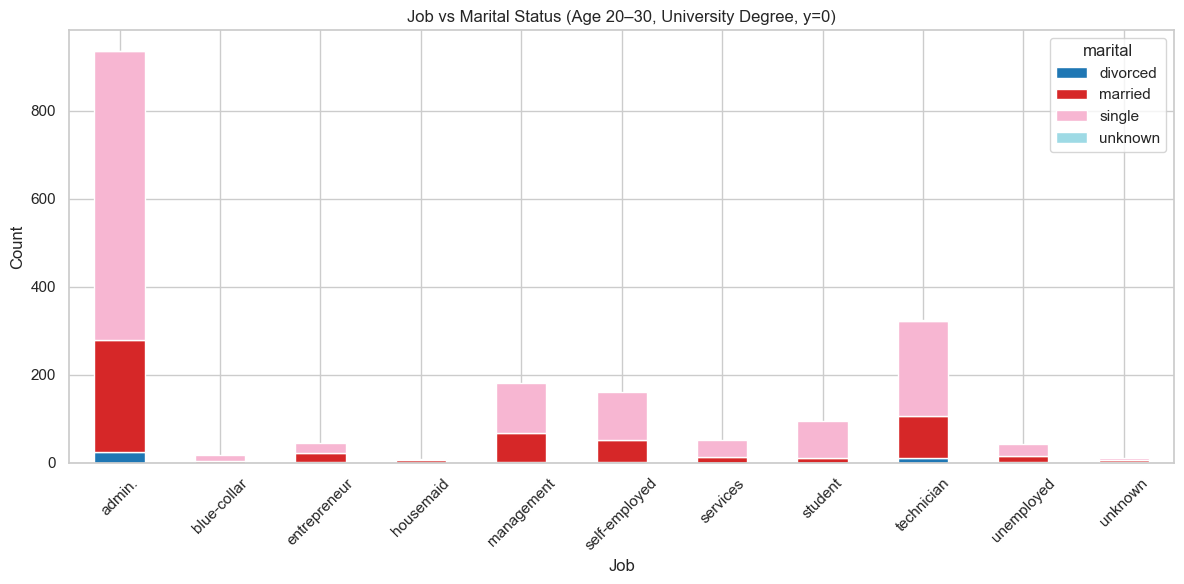

In [ ]:
# marital vs job for y=0
b = df_age_between_20_30[(df_age_between_20_30['education']=='university.degree')&( df_age_between_20_30['y']==0 )]['job']
print(pd.crosstab(b, df_age_between_20_30['marital']))

# plot
ct = pd.crosstab(b, df_age_between_20_30['marital'])

ct.plot(kind='bar', stacked=True, figsize=(12,6), colormap='tab20')
plt.title('Job vs Marital Status (Age 20–30, University Degree, y=0)')
plt.xlabel('Job')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

marital        divorced  married  single  unknown
job                                              
admin.                4       52     171        0
blue-collar           0        0       4        0
entrepreneur          0        2       5        0
housemaid             0        0       1        0
management            0       14      22        0
self-employed         3        7      21        0
services              0        1       5        0
student               0        3      20        0
technician            2        9      44        2
unemployed            0        2       9        0
unknown               0        0       7        0


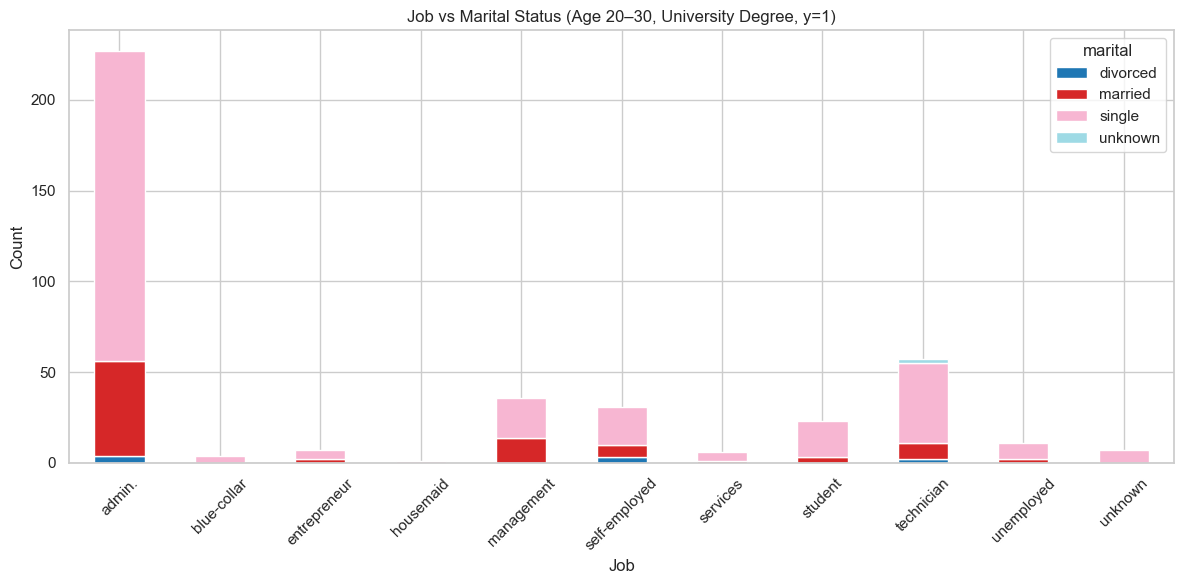

In [ ]:
# marital vs job for y=1
a = df_age_between_20_30[(df_age_between_20_30['education']=='university.degree')&( df_age_between_20_30['y']==1 )]['job']
print(pd.crosstab(a, df_age_between_20_30['marital']))

ct = pd.crosstab(a, df_age_between_20_30['marital'])

ct.plot(kind='bar', stacked=True, figsize=(12,6), colormap='tab20')
plt.title('Job vs Marital Status (Age 20–30, University Degree, y=1)')
plt.xlabel('Job')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**Findings**:
1. Young customers prefer cellular contact, with fewer campaign attempts and shorter contact durations.
2. This segment tends to be single, have good credit standing, and carry no loan burden.
3. Re-subscription rates remain high across both the young and overall segments.
4. Among customers with **no prior contact**, the **young group shows a higher subscription rate** than the overall group (11% vs. 8%).
5. Among customers with **previously failed campaigns**, **the young group shows a higher re-conversion rate** than the overall group (16% vs. 14%).

In summary, both **cold outreach and re-marketing efforts should prioritise customers aged 20–30**. Re-subscription rates are consistently high regardless of age group.

# Key Findings & Recommendations

**Findings:**
- **High-value segment:** customers aged 20-30 with university degrees show the highest subscription rate (17.8%) — 1.6x overall average
- **Low-value segment:** blue-collar workers consistently show the lowest subscription rates (<7.5%)
- **Loyalty effect:** previous subscribers (poutcome = success) have 65% re-subscription rate — 6x overall average
- **Contact behaviour:** subscribers have lower contact frequency (campaign = 1-2)
- **Channel preference:** cellular outperforms telephone (14.3% vs ~5%)
- **Seasonal pattern:** March and October show highest subscription rates; May shows lowest

**Recommendations:**
- Prioritise 20-30 university-educated customers and previous subscribers for campaigns
- Contact via cellular and limit to 1-2 contacts per customer
- Schedule campaigns in March or October; avoid May
- Deprioritise blue-collar workers to reduce wasted resources
- Duration should be excluded before modelling due to data leakage risk